# LKIPA Time Series Data Collection

In this notebook we develop the script to collect time series data from the LKIPA. 

- PUMP OFF
- PUMP ON (Sub-Threshold)
- PUMP ON (Threshold)
- PUMP ON (Super-Threshold)

PUMP OFF data is required to quantify the background noise level and frequency spectrum to subtract from the PUMP ON cases. 

----

In [1]:
# IMPORTS
# =======
import os
import sys

import matplotlib.pyplot as plt
%matplotlib widget
import numpy as np
from tqdm import tqdm
from IPython.display import display, clear_output
import time

from presto import test
from presto import lockin, utils
from presto.hardware import AdcMode, DacMode, AdcFSample, DacFSample

import importlib
import LKIPA_library as lib
importlib.reload(lib)

<module 'LKIPA_library' from '/home/nanophys-meas/Desktop/Jai Master Thesis/Presto-Measurement-Scripts/LKIPA Time-Frequency Analysis/LKIPA_library.py'>

## 1. PRESTO Configuration

In [2]:
###### ------MEASUREMENT CONFIGURATION------ ######

# Sampling resolution
dt = 1e-9

# FFT resolution
DF = 100e3                                      # Hz

# Pump power sweep list (FS)
PUMP_AMP_LIST = [1.0] #np.arange(0, 1.0, 0.2)    # amplitude of pump signal, 0 for vacuum

# DC bias (V)
DC_BIAS = 3.5 

# Resonator frequency (Hz)
RES_FREQ = 4.4242e9                             # Set based on latest PSD/Covariance measurements, Hz

# Pump frequency for PRESTO  (Hz)
PUMP_FREQ = 2 * RES_FREQ - lib.PUMP_NCO         # Hz, 0 to 500 MHz, intermediate frequency

# Number of pixels to be captured
N_PIX = 1000            

### Notes

- dcb 3.5, f0 4.4242

## 2. Data Acquisition Loop

In [3]:
# DATA ACQUISITION

myrun = time.strftime("%Y-%m-%d_%H_%M_%S") 
lib.data_acquisition(
    address=lib.ADDRESS,
    port=lib.PORT,
    converter_configuration=lib.CONVERTER_CONFIGURATION,
    input_port=lib.INPUT_PORT,
    adc_att=lib.ADC_ATT,
    input_nco=RES_FREQ - 4e9,  # Set input NCO to resonator frequency to directly capture the downconverted signal at baseband
    output_port=lib.FLUX_PORT,
    dac_curr=lib.DAC_CURR,
    amp_list=PUMP_AMP_LIST,
    freq=PUMP_FREQ,
    phasei=lib.PHASEI,
    phaseq=lib.PHASEQ,
    output_nco=lib.PUMP_NCO,
    df=DF,
    dcb_port=lib.DC_PORT,
    dcb_amp=DC_BIAS,
    n_pix=N_PIX,
    myrun=myrun,
)

Presto outputs reset to 0, data acquisition complete.

MEASUREMENT PARAMETERS:
Mode: AdcMode.Mixed
Number of pixels: 1000
Pixel time resolution (dt): 1.00 ns
Sampling frequency (fs): 1.00 GHz
Total measurement time: 10.0 µs
Frequency resolution (DF): 100.0 kHz


## 2 Remove DC Bias, extract quadratures, compute autocorrelations

In [4]:
folder =f"Time series raw data/{myrun}"

I_all_list = []
Q_all_list = []

for pump_amp in PUMP_AMP_LIST:

    data = np.loadtxt(fname=f"{folder}/data_DF={DF/1e3:.1f}kHz_amp={pump_amp:.2f}_pixels={N_PIX}.txt")
    I_all, Q_all = lib.remove_DC(data_all=data, n_pix=N_PIX, converter_configuration=lib.CONVERTER_CONFIGURATION, verbose=True)

    I_all_list.append(I_all)
    Q_all_list.append(Q_all)
    
I_all_list = np.array(I_all_list)
Q_all_list = np.array(Q_all_list)

Data format: Mixed mode (I and Q interleaved)
Shape of I data: (1000, 10000)


In [5]:

n_samples = np.shape(I_all_list)[2]

auto_xx_list = np.zeros((N_PIX, n_samples))
auto_pp_list = np.zeros((N_PIX, n_samples))
cross_xp_list = np.zeros((N_PIX, n_samples))

pump_idx = 0

with tqdm(total= N_PIX, ncols = 80) as pbar:
    for pix in range(N_PIX):
        auto_xx_list[pix] = np.correlate(
            a=I_all_list[pump_idx][pix], 
            v=I_all_list[pump_idx][pix],
            mode='same'
        )

        auto_pp_list[pix] = np.correlate(
                a=Q_all_list[pump_idx][pix], 
                v=Q_all_list[pump_idx][pix],
                mode='same'
                )

        cross_xp_list[pix] = np.correlate(

                a=I_all_list[pump_idx][pix],
                v=Q_all_list[pump_idx][pix],
                mode='same'
        )
        pbar.update(1)

auto_xx = np.mean(auto_xx_list, axis=0)
auto_pp = np.mean(auto_pp_list, axis=0)
cross_xp = np.mean(cross_xp_list, axis=0)

100%|███████████████████████████████████████| 1000/1000 [00:48<00:00, 20.68it/s]


<>:15: SyntaxWarning: invalid escape sequence '\m'
<>:15: SyntaxWarning: invalid escape sequence '\m'
/tmp/ipykernel_1001889/1003475795.py:15: SyntaxWarning: invalid escape sequence '\m'
  ax.set_xlabel("Time $(\mu s)$")


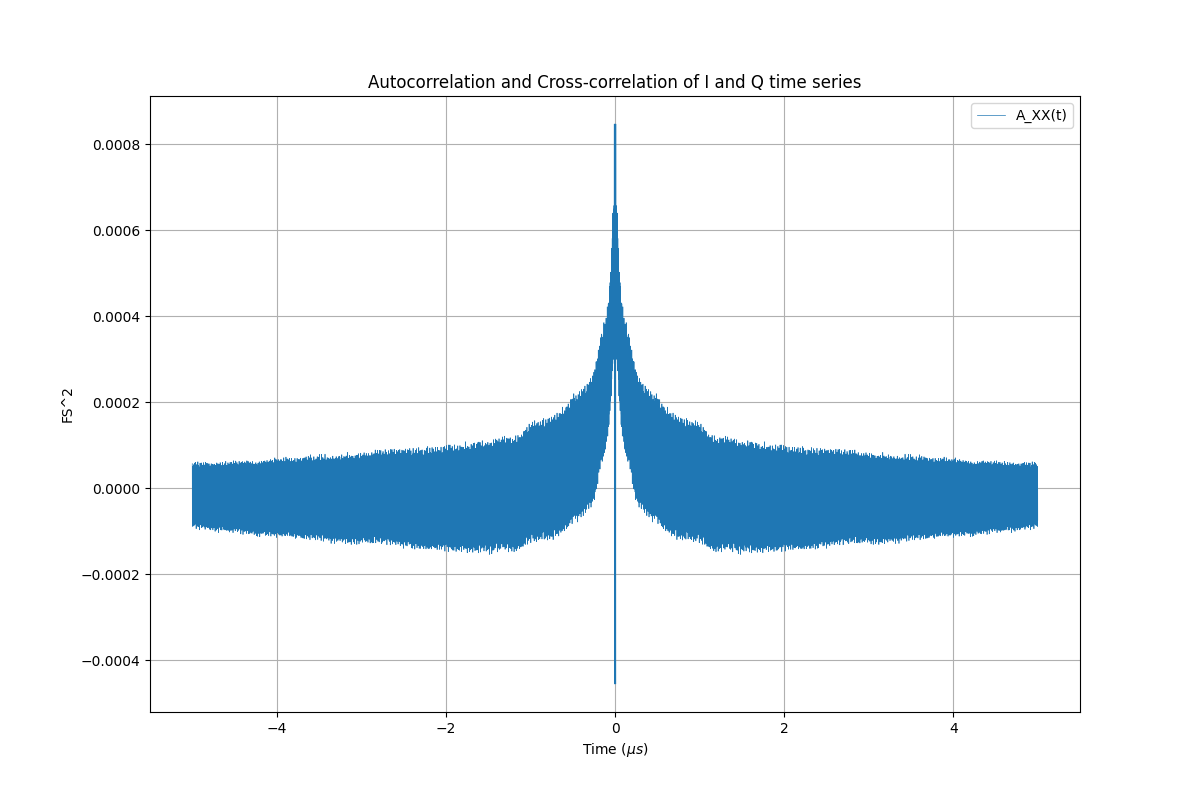

In [11]:
# time array
t_list = (1e6 * dt) * np.concatenate([np.arange(-n_samples//2, 0), np.arange(1, n_samples//2)])

auto_xx_delta_removed = np.concatenate([auto_xx[:n_samples//2], auto_xx[n_samples//2+1:],])
auto_pp_delta_removed = np.concatenate([auto_pp[:n_samples//2], auto_pp[n_samples//2+1:]])
cross_xp_delta_removed = np.concatenate([cross_xp[:n_samples//2], cross_xp[n_samples//2+1:]])

# Plot
fig, ax = plt.subplots(figsize=(12, 8))
ax.plot(t_list, auto_xx_delta_removed , label=f"A_XX(t)", lw=0.5)
#ax.plot(t_list, auto_pp_delta_removed, label=f"A_PP(t)", lw=0.5)
#ax.plot(t_list, cross_xp_delta_removed, label=f"C_XP(t)", lw=0.5)
ax.legend()
ax.grid()
ax.set_xlabel("Time $(\mu s)$")
ax.set_ylabel("FS^2")
ax.set_title("Autocorrelation and Cross-correlation of I and Q time series")
plt.show()


In [7]:
# n_samples = np.shape(I_all_list)[2]

# auto_xx_pump = np.zeros((len(PUMP_AMP_LIST), n_samples))
# auto_pp_pump = np.zeros((len(PUMP_AMP_LIST), n_samples))
# cross_xp_pump = np.zeros((len(PUMP_AMP_LIST), n_samples))

# # Loop through each pump amplitude
# with tqdm(total= len(PUMP_AMP_LIST), ncols = 80) as pbar1:
#     for pump_idx, pump_amp in enumerate(PUMP_AMP_LIST):

#         auto_xx_list = np.zeros(( N_PIX, n_samples))
#         auto_pp_list = np.zeros(( N_PIX, n_samples))
#         cross_xp_list = np.zeros(( N_PIX, n_samples))
#         # loop through each pixel
#         with tqdm(total= N_PIX, ncols = 80) as pbar2:
#             for pix in range(N_PIX):
#                 auto_xx_list[pix] = np.correlate(

#                     a=I_all_list[pump_idx][pix], 
#                     v=I_all_list[pump_idx][pix],
#                     mode='same'
#                 )

#                 auto_pp_list[pix] = np.correlate(

#                         a=Q_all_list[pump_idx][pix], 
#                         v=Q_all_list[pump_idx][pix],
#                         mode='same'
#                         )

#                 cross_xp_list[pix] = np.correlate(

#                         a=I_all_list[pump_idx][pix],
#                         v=Q_all_list[pump_idx][pix],
#                         mode='same'
#                 )
#                 pbar2.update(1)
#         # average over all pixels for the current pump amplitude
#         auto_xx_pump[pump_idx] = np.mean(auto_xx_list, axis=0)
#         auto_pp_pump[pump_idx] = np.mean(auto_pp_list, axis=0)
#         cross_xp_pump[pump_idx] = np.mean(cross_xp_list, axis=0)

#         pbar1.update(1)

In [8]:
# # time array
# t_list = (1e6 * dt) * np.concatenate([np.arange(-n_samples//2, 0), np.arange(1, n_samples//2)])

# pump_idx = 0

# auto_xx_delta_removed = np.concatenate([auto_xx_pump[pump_idx][:n_samples//2], auto_xx_pump[pump_idx][n_samples//2+1:]])
# auto_pp_delta_removed = np.concatenate([auto_pp_pump[pump_idx][:n_samples//2], auto_pp_pump[pump_idx][n_samples//2+1:]])
# cross_xp_delta_removed = np.concatenate([cross_xp_pump[pump_idx][:n_samples//2], cross_xp_pump[pump_idx][n_samples//2+1:]])

# # Plot
# fig, ax = plt.subplots(figsize=(8, 8))

# #ax.plot( auto_xx_pump[pump_idx], label=f"Test correlation")
# #ax.plot(t_list, auto_xx_delta_removed, label=f"A_XX(t)")
# #ax.plot(t_list, auto_pp_delta_removed, label=f"A_PP(t)")
# ax.plot(t_list, cross_xp_delta_removed, label=f"C_XP(t)")
# ax.legend()
# ax.set_xlabel("Time $(\\mu s)$")
# ax.set_ylabel("FS^2")
# ax.set_title("Autocorrelation and Cross-correlation of I and Q time series")
# plt.show()